# Client test

In [1]:
from services.simulation_service import simulate_circuit
from qiskit import QuantumCircuit
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import time

In [2]:
def dict_builder(nq, clb, initial_state, algorithm, runner_mode, noise_model, shots):
    initial_instructions = []
    for c, i in zip(initial_state, range(nq)):
        if c == '1':
            initial_instructions.append({"name": "X", "qubits": [i]})
    
    if runner_mode == 'shot': algorithm.append({"name": "MEASURE_ALL"})

    instructions = initial_instructions + algorithm
    
    return {
        "name": "Testing",
        "num_qubits": nq,
        "num_clbits": clb,
        "instructions": instructions,
        "runner_mode": runner_mode,
        "noise_model": noise_model,
        "shots": shots
    }

In [13]:
nq = 4
clb = 4
initial_state = '0100'
runner_mode = 'shot'
noise_model = 'depolarizing'
shots = 1024

algorithm_instructions = [
                            #{"name": "H", "qubits": [0]},
                            #{"name": "CX", "qubits": [0,1]},
                            #{"name": "CX", "qubits": [0,2]},
                            #{"name": "CX", "qubits": [0,3]},
                            {"name": "SUM", "qubits": [0,1,2,3]},
                        ]

dicccionary = dict_builder(nq, clb, initial_state, algorithm_instructions, runner_mode, noise_model, shots)

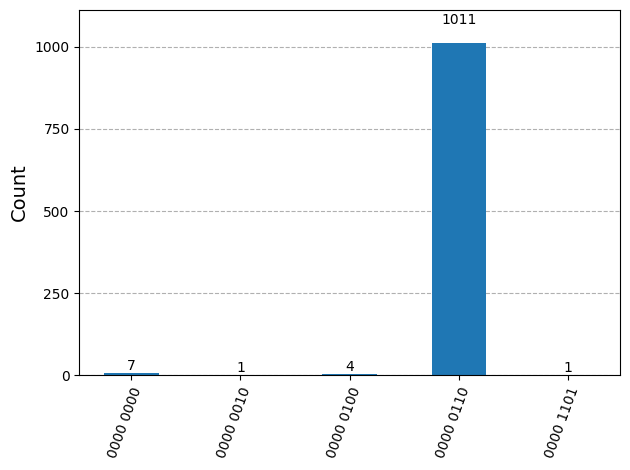

In [14]:
result = simulate_circuit(dicccionary, time.time())

counts = result.get('output').get('results')

plot_histogram(counts)